# Wind Forecast Error Analysis

This notebook analyses the accuracy of UK national wind power forecasts using data from the Elexon BMRS API. Three questions drive the analysis:

1. **Horizon decay** - how quickly does accuracy degrade as the forecast looks further ahead, and is there a reliability cliff?
3. **Temporal patterns** - does forecast error cluster at particular hours, months, or seasons?

Data covers January 2024 onwards, with forecast horizons capped at 0-48 hours per the dataset specification.

In [1]:
import os
import json
import time
from datetime import datetime, timedelta, timezone

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

In [2]:
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.alpha": 0.3,
    "font.size": 11,
    "figure.facecolor": "white",
})

BASE_URL = "https://data.elexon.co.uk/bmrs/api/v1/datasets"
START_DATE = datetime(2024, 1, 1, tzinfo=timezone.utc)
END_DATE = datetime.now(timezone.utc).replace(hour=0, minute=0, second=0, microsecond=0)

DEFAULT_HORIZON_HRS = 4

CACHE_DIR = "data_cache"
os.makedirs(CACHE_DIR, exist_ok=True)

## 1. Data Fetching



In [3]:
HEADERS = {"Accept": "application/json"}


def fetch_forecast(from_dt: datetime, to_dt: datetime) -> list:
    url = (
        f"{BASE_URL}/WINDFOR/stream"
        f"?publishDateTimeFrom={from_dt.strftime('%Y-%m-%dT%H:%M:%SZ')}"
        f"&publishDateTimeTo={to_dt.strftime('%Y-%m-%dT%H:%M:%SZ')}"
    )
    resp = requests.get(url, headers=HEADERS, timeout=90)
    resp.raise_for_status()
    data = resp.json()
    return data if isinstance(data, list) else data.get("data", [])


def fetch_actual(from_dt: datetime, to_dt: datetime) -> list:
    url = (
        f"{BASE_URL}/FUELHH/stream"
        f"?settlementDateFrom={from_dt.strftime('%Y-%m-%d')}"
        f"&settlementDateTo={to_dt.strftime('%Y-%m-%d')}"
        f"&fuelType=WIND"
    )
    resp = requests.get(url, headers=HEADERS, timeout=90)
    resp.raise_for_status()
    data = resp.json()
    return data if isinstance(data, list) else data.get("data", [])


def load_dataset(name: str, fetch_fn) -> list:
    cache_path = os.path.join(CACHE_DIR, f"{name}.json")
    if os.path.exists(cache_path):
        print(f"Loading from cache")
        with open(cache_path) as f:
            return json.load(f)

    print(f"Fetching from API")
    all_records = []
    cursor = START_DATE
    while cursor < END_DATE:
        chunk_end = min(cursor + timedelta(days=7), END_DATE)
        print(f"{cursor.date()} to {chunk_end.date()}", end=" ")
        try:
            records = fetch_fn(cursor, chunk_end)
            all_records.extend(records)
            print(f"({len(records)} rows)")
        except requests.HTTPError as e:
            print(f"HTTP {e.response.status_code}")
        cursor = chunk_end
        time.sleep(0.3)

    with open(cache_path, "w") as f:
        json.dump(all_records, f)
    print(f"Cached {len(all_records):,} rows to {cache_path}")
    return all_records


print("Fetching forecasts")
raw_forecasts = load_dataset("FORECAST", fetch_forecast)

print("\nFetching actuals")
raw_actuals = load_dataset("ACTUAL", fetch_actual)

print(f"\nForecasts: {len(raw_forecasts):,}   Actuals: {len(raw_actuals):,}")

Fetching forecasts
Fetching from API
2024-01-01 to 2024-01-08 (2744 rows)
2024-01-08 to 2024-01-15 (2744 rows)
2024-01-15 to 2024-01-22 (2744 rows)
2024-01-22 to 2024-01-29 (2744 rows)
2024-01-29 to 2024-02-05 (2744 rows)
2024-02-05 to 2024-02-12 (2744 rows)
2024-02-12 to 2024-02-19 (2744 rows)
2024-02-19 to 2024-02-26 (2744 rows)
2024-02-26 to 2024-03-04 (2744 rows)
2024-03-04 to 2024-03-11 (2744 rows)
2024-03-11 to 2024-03-18 (2744 rows)
2024-03-18 to 2024-03-25 (2744 rows)
2024-03-25 to 2024-04-01 (2728 rows)
2024-04-01 to 2024-04-08 (2744 rows)
2024-04-08 to 2024-04-15 (2744 rows)
2024-04-15 to 2024-04-22 (2744 rows)
2024-04-22 to 2024-04-29 (2744 rows)
2024-04-29 to 2024-05-06 (2744 rows)
2024-05-06 to 2024-05-13 (2744 rows)
2024-05-13 to 2024-05-20 (2744 rows)
2024-05-20 to 2024-05-27 (2744 rows)
2024-05-27 to 2024-06-03 (2744 rows)
2024-06-03 to 2024-06-10 (2744 rows)
2024-06-10 to 2024-06-17 (2744 rows)
2024-06-17 to 2024-06-24 (2744 rows)
2024-06-24 to 2024-07-01 (2744 rows)
2

## 2. Inspect records

In [4]:
print("Forecast sample")
print(json.dumps(raw_forecasts[0], indent=2) if raw_forecasts else "empty")
print("\nActual sample")
print(json.dumps(raw_actuals[0], indent=2) if raw_actuals else "empty")

Forecast sample
{
  "dataset": "WINDFOR",
  "publishTime": "2024-01-07T22:30:00Z",
  "startTime": "2024-01-07T21:00:00Z",
  "generation": 4162
}

Actual sample
{
  "dataset": "FUELHH",
  "publishTime": "2024-01-09T00:00:00Z",
  "startTime": "2024-01-08T23:30:00Z",
  "settlementDate": "2024-01-08",
  "settlementPeriod": 48,
  "fuelType": "WIND",
  "generation": 11909
}


## 3. Preprocessing

Two datasets are built from the raw data:

- **`merged_all`**: every forecast matched to its actual, retaining all horizon values. Used only for Analysis A (horizon decay), where we deliberately want to compare errors across all lead times.
- **`merged_ops`**: one forecast per 30-minute target time, selected using the same rule as `processDatasets` in the app: *the latest forecast published at or before `targetTime: DEFAULT_HORIZON_HRS`*. This is what the app actually shows the user, so it's the right basis for analyses B and C.

In [5]:
actuals = (
    pd.DataFrame(raw_actuals)
    .rename(columns=str.strip)
    [["startTime", "generation"]]
    .rename(columns={"generation": "actual_mw"})
    .assign(startTime=lambda d: pd.to_datetime(d["startTime"], utc=True))
    .drop_duplicates("startTime")
    .sort_values("startTime")
    .reset_index(drop=True)
)

forecasts = (
    pd.DataFrame(raw_forecasts)
    .rename(columns=str.strip)
    [["startTime", "publishTime", "generation"]]
    .rename(columns={"generation": "forecast_mw"})
    .assign(
        startTime   = lambda d: pd.to_datetime(d["startTime"],   utc=True),
        publishTime = lambda d: pd.to_datetime(d["publishTime"], utc=True),
    )
    .dropna(subset=["startTime", "publishTime", "forecast_mw"])
    .reset_index(drop=True)
)

forecasts["horizon_hrs"] = (
    (forecasts["startTime"] - forecasts["publishTime"]).dt.total_seconds() / 3600
)
forecasts = forecasts.query("0 <= horizon_hrs <= 48").copy()

print(f"Actuals: {len(actuals):,} rows")
print(f"Forecasts: {len(forecasts):,} rows | horizon {forecasts['horizon_hrs'].min():.1f}–{forecasts['horizon_hrs'].max():.1f} hrs")
print(f"\nActual startTime range: {actuals['startTime'].min()} to {actuals['startTime'].max()}")
print(f"Forecast startTime range: {forecasts['startTime'].min()} to {forecasts['startTime'].max()}")

Actuals: 39,089 rows
Forecasts: 292,172 rows | horizon 0.0–48.0 hrs

Actual startTime range: 2024-01-01 00:00:00+00:00 to 2026-03-25 08:00:00+00:00
Forecast startTime range: 2024-01-01 21:00:00+00:00 to 2026-03-26 21:00:00+00:00


In [6]:
def add_error_cols(df: pd.DataFrame) -> pd.DataFrame:
    return df.assign(
        error = lambda d: d["forecast_mw"] - d["actual_mw"],
        abs_error = lambda d: (d["forecast_mw"] - d["actual_mw"]).abs(),
        pct_error = lambda d: ((d["forecast_mw"] - d["actual_mw"]).abs()
                               / d["actual_mw"].replace(0, np.nan)) * 100,
    )


def add_time_cols(df: pd.DataFrame) -> pd.DataFrame:
    return df.assign(
        hour = df["startTime"].dt.hour,
        month = df["startTime"].dt.month,
        month_name = df["startTime"].dt.strftime("%b"),
    )

merged_all = add_time_cols(add_error_cols(
    forecasts.merge(actuals, on="startTime", how="inner")
))


def select_operational_forecast(group: pd.DataFrame, horizon_hrs: float) -> pd.Series | None:
    target_time = group["startTime"].iloc[0]
    cutoff = target_time - pd.Timedelta(hours=horizon_hrs)
    valid = group[group["publishTime"] <= cutoff]
    if valid.empty:
        return None
    return valid.loc[valid["publishTime"].idxmax()]


forecasts_sorted = forecasts.sort_values(["startTime", "publishTime"])
forecasts_sorted["cutoff"] = forecasts_sorted["startTime"] - pd.Timedelta(hours=DEFAULT_HORIZON_HRS)
valid = forecasts_sorted[forecasts_sorted["publishTime"] <= forecasts_sorted["cutoff"]]
ops_rows = valid.loc[valid.groupby("startTime")["publishTime"].idxmax()].reset_index(drop=True)

merged_ops = add_time_cols(add_error_cols(
    ops_rows.merge(actuals, on="startTime", how="inner")
))


def print_summary(name: str, df: pd.DataFrame):
    if len(df) == 0:
        print(f"{name}: 0 rows")
        return
    print(f"{name}")
    print(f"Rows: {len(df):,}")
    print(f"Date range: {df['startTime'].min().date()} to {df['startTime'].max().date()}")
    print(f"Mean Absolute Error: {df['abs_error'].mean():.0f} MW")
    print(f"Root Mean Squared Error: {np.sqrt((df['error']**2).mean()):.0f} MW")
    print(f"Median bias: {df['error'].median():.0f} MW")


print_summary("merged_all (Used for Analysis A)", merged_all)
print()
print_summary(f"merged_ops (Used for B & C)", merged_ops)

merged_all (Used for Analysis A)
Rows: 291,923
Date range: 2024-01-01 to 2026-03-25
Mean Absolute Error: 1626 MW
Root Mean Squared Error: 2132 MW
Median bias: 1044 MW

merged_ops (Used for B & C)
Rows: 19,524
Date range: 2024-01-01 to 2026-03-25
Mean Absolute Error: 1461 MW
Root Mean Squared Error: 1964 MW
Median bias: 945 MW


---
## Analysis A: Forecast Horizon Decay

Uses `merged_all` so every horizon value is represented. The goal is not just to confirm that accuracy degrades, but to find how fast and whether there is a cliff.

In [7]:
bin_edges = np.arange(0, 50, 2)
merged_all["horizon_bin"] = pd.cut(merged_all["horizon_hrs"], bins=bin_edges, right=False)

horizon_stats = (
    merged_all
    .groupby("horizon_bin", observed=True)
    .agg(
        mae = ("abs_error", "mean"),
        rmse = ("error", lambda x: np.sqrt((x**2).mean())),
        p75 = ("abs_error", lambda x: x.quantile(0.75)),
        p95 = ("abs_error", lambda x: x.quantile(0.95)),
        bias = ("error", "mean"),
        count = ("error", "count"),
    )
    .reset_index()
)
horizon_stats["horizon_mid"] = bin_edges[:-1] + 1

baseline_mae = horizon_stats.loc[horizon_stats["horizon_mid"] == 1, "mae"].values[0]
threshold = baseline_mae * 1.5
cliff_rows = horizon_stats.loc[horizon_stats["mae"] >= threshold, "horizon_mid"]
cliff_at = cliff_rows.values[0] if len(cliff_rows) else None

print(f"Baseline MAE (0–2 hr): {baseline_mae:.0f} MW")
print(f"1.5x threshold: {threshold:.0f} MW")
print(f"Reliability cliff at: {cliff_at} hrs" if cliff_at else "No cliff within 48 hrs")

Baseline MAE (0–2 hr): 1434 MW
1.5x threshold: 2151 MW
No cliff within 48 hrs


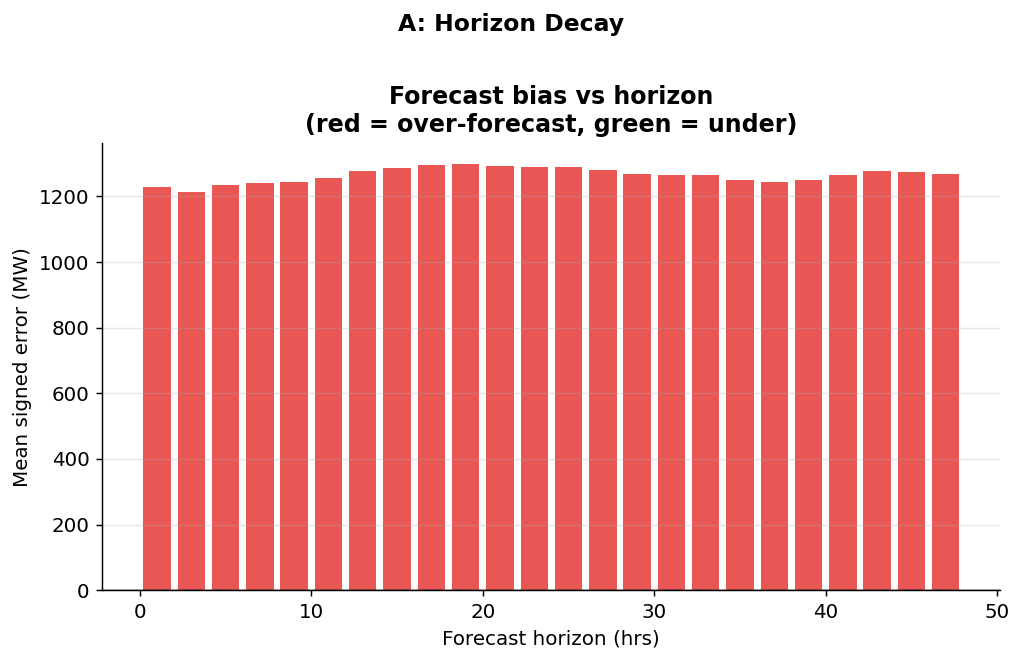

In [8]:
fig, ax1 = plt.subplots(1, 1, figsize=(8, 5))
x = horizon_stats["horizon_mid"]

bar_colors = ["#E53935" if b > 0 else "#43A047" for b in horizon_stats["bias"]]
ax1.bar(x, horizon_stats["bias"], width=1.6, color=bar_colors, alpha=0.85)
ax1.axhline(0, color="black", lw=0.8)
ax1.set_xlabel("Forecast horizon (hrs)")
ax1.set_ylabel("Mean signed error (MW)")
ax1.set_title("Forecast bias vs horizon\n(red = over-forecast, green = under)", fontweight="bold")

plt.suptitle("A: Horizon Decay", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("horizon_decay.png", bbox_inches="tight")
plt.show()

### Observations: Horizon Decay

The model consistently over-predicts wind generation by approximately 1,200–1,300 MW regardless of how far ahead the forecast is made. This is not a subtle bias — it represents a structural tendency to overestimate output.

The bars are nearly flat from 0 to 48 hours. This is surprising, you would normally expect short horizon forecasts to be better calibrated than long range ones. The fact that the bias is just as large at 2 hours as at 48 hours suggests the over forecasting is not a consequence of forecast uncertainty but a systematic model offset.

A consistent 1,250 MW over forecast means the grid is routinely expecting more wind than arrives. This is operationally significant as it would cause persistent under procurement of backup capacity. The right response is not to use a different horizon, but to apply a flat bias correction to all forecasts.

---
## Analysis B: Temporal Error Patterns

Also uses `merged_ops` for the same reason that one operational forecast per target time gives a clean picture of when the model struggles in practice.

In [9]:
hourly = (
    merged_ops.groupby("hour")
    .agg(
        mae = ("abs_error", "mean"),
        bias = ("error", "mean"),
        p75 = ("abs_error", lambda x: x.quantile(0.75)),
    )
    .reset_index()
)

month_order = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]
monthly = (
    merged_ops.groupby(["month", "month_name"])
    .agg(
        mae = ("abs_error", "mean"),
        bias = ("error",     "mean"),
        actual_mean = ("actual_mw", "mean"),
    )
    .reset_index()
    .sort_values("month")
)
available = [m for m in month_order if m in monthly["month_name"].values]
monthly = monthly.set_index("month_name").loc[available].reset_index()

pivot_mae = (
    merged_ops.groupby(["month_name", "hour"])["abs_error"]
    .mean().unstack("hour")
    .reindex([m for m in month_order if m in merged_ops["month_name"].unique()])
)
pivot_bias = (
    merged_ops.groupby(["month_name", "hour"])["error"]
    .mean().unstack("hour")
    .reindex([m for m in month_order if m in merged_ops["month_name"].unique()])
)

print(f"Worst hour (MAE): {hourly.loc[hourly['mae'].idxmax(), 'hour']:02d}:00 ({hourly['mae'].max():.0f} MW)")
print(f"Best hour (MAE): {hourly.loc[hourly['mae'].idxmin(), 'hour']:02d}:00 ({hourly['mae'].min():.0f} MW)")
if len(monthly) > 1:
    print(f"Worst month (MAE): {monthly.loc[monthly['mae'].idxmax(), 'month_name']} ({monthly['mae'].max():.0f} MW)")
    print(f"Best month (MAE): {monthly.loc[monthly['mae'].idxmin(), 'month_name']} ({monthly['mae'].min():.0f} MW)")

Worst hour (MAE): 04:00 (1596 MW)
Best hour (MAE): 16:00 (1344 MW)
Worst month (MAE): Oct (1820 MW)
Best month (MAE): May (914 MW)


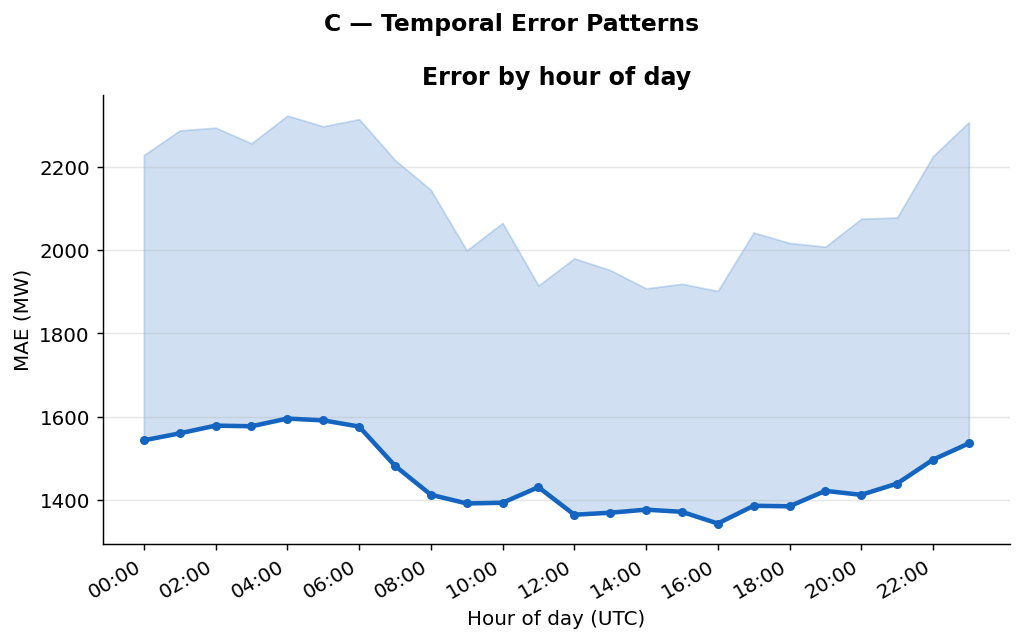

In [10]:
fig, ax2 = plt.subplots(1, 1, figsize=(8, 5))

ax2.fill_between(hourly["hour"], hourly["mae"], hourly["p75"], alpha=0.2, color="#1565C0")
ax2.plot(hourly["hour"], hourly["mae"], color="#1565C0", lw=2.5, marker="o", ms=4)
ax2.set_xticks(range(0, 24, 2))
ax2.set_xticklabels([f"{h:02d}:00" for h in range(0, 24, 2)], rotation=30, ha="right")
ax2.set_xlabel("Hour of day (UTC)")
ax2.set_ylabel("MAE (MW)")
ax2.set_title("Error by hour of day", fontweight="bold")

plt.suptitle("C — Temporal Error Patterns", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("temporal_patterns.png", bbox_inches="tight")
plt.show()

### Observations: Temporal Error Patterns

MAE peaks between 00:00 and 07:00 UTC, reaching around 1,580–1,600 MW, with the worst point at 04:00.

MAE drops sharply after 07:00 and reaches its lowest point around 12:00–16:00 UTC (1,340–1,380 MW). This likely reflects better observational data assimilation during active forecaster hours, and more stable atmospheric conditions during the day.

Forecasts issued for overnight and early morning target times deserve more scrutiny.

---
# Wind Generation Reliability Analysis
Dataset: Jan 2024 – Mar 2026 | 38,913 half-hour observations

### What the data looks like overall

Wind generation across this period ranged from 0 MW to 18,439 MW, with a mean of 7,969 MW and median of 7,528 MW. The standard deviation is 4,395 MW, meaning generation is highly volatile, swinging roughly ±4,000 MW around the average on a typical day. This alone tells you the mean is a useless planning number.

### Exceedance Picture

| MW level | % of time exceeded |
|---|---|
| 1,000 MW | 98.0% |
| 1,500 MW | 95.8% |
| 2,000 MW | 92.7% |
| **2,392 MW** | **90.0% ← P10** |
| 3,000 MW | 85.3% |
| 5,000 MW | 69.0% |

So if you need a number that wind will deliver 90% of all half-hours, it's ~2,400 MW. 95% reliability drops to ~1,630 MW.

### Seasonal Story

| Season | Mean | P10 | P5 |
|---|---|---|---|
| Winter | 10,203 MW | 4,121 MW | 2,647 MW |
| Autumn | 8,297 MW | 2,625 MW | 1,626 MW |
| Spring | 6,959 MW | 2,050 MW | 1,469 MW |
| **Summer** | **5,855 MW** | **1,865 MW** | **1,212 MW** |

Winter is actually the most reliable season for wind, even though it has the highest electricity demand. The UK's windiest months line up with peak consumption, which works in our favour. Summer is where the risk lies.

July stands out as the worst month by far. Wind drops below 2,000 MW in 1 out of every 6 July half hours, and the P10 floor is just 1,460 MW. February sits at the opposite end, with a P10 of 4,537 MW, it is three times more reliable than July.

### Recommendation

For year-round planning, wind will deliver at least 1,500 MW around 96% of the time. This is a safe number to build capacity plans around. In summer however, this floor drops to around 1,200 MW, so summer planning should use the lower number.

or reserve sizing, use 750 MW as the minimum wind contribution you can count on in summer. This is the P5 for July, meaning in the worst summer conditions, wind will still deliver at least 750 MW around 95% of the time. Any backup capacity plan should assume wind contributes no more than this floor during a summer stress event.

Low wind periods can last multiple days, not just a few hours. The longest event in this dataset ran for 61 hours straight in August 2025. This means backup capacity needs to be able to run for 2 to 3 days continuously, battery storage alone is not sufficient for this.